# Superstore Sales and Profitability Analysis

Questa analisi si basa sul dataset **Sample - Superstore**, un dataset retail statunitense di esempio. L’obiettivo è dimostrare competenze trasferibili di data analysis e KPI reporting.

## 1. Data Loading

In [301]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PRIMARY_COLOR = "#4C72B0"
SECONDARY_COLOR = "#55A868"
ACCENT_COLOR = "#C44E52"
NEUTRAL_COLOR = "#6C757D"
WARNING_COLOR = "#DD8452"
SEGMENT_PALETTE = {
    "Consumer": PRIMARY_COLOR,
    "Corporate": "#DD8452",
    "Home Office": SECONDARY_COLOR
}

df = pd.read_csv("data/Sample - Superstore.csv")

display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Initial Data Exploration

Prima di pulire o trasformare i dati, verifichiamo struttura, tipi di dato, valori mancanti e duplicati.

In [302]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

In [303]:
missing_summary = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing Values"})
)

display(missing_summary)

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

,Column,Missing Values
0,Row ID,0
1,Order ID,0
2,Order Date,0
3,Ship Date,0
4,Ship Mode,0
5,Customer ID,0
6,Customer Name,0
7,Segment,0
8,Country,0
9,City,0


Duplicate rows: 0


## 3. Data Cleaning and Preparation

Il dataset non presenta valori mancanti evidenti.  
Le principali operazioni di preparazione sono:

- conversione delle date in formato `datetime`;
- conversione del codice postale in testo;
- creazione di variabili temporali;
- creazione del margine di profitto;
- identificazione degli ordini in profitto o in perdita.

I profitti negativi non vengono eliminati perché rappresentano informazioni importanti per l’analisi.

In [304]:
clean_df = df.copy()

clean_df["Order Date"] = pd.to_datetime(clean_df["Order Date"], format="%m/%d/%Y")
clean_df["Ship Date"] = pd.to_datetime(clean_df["Ship Date"], format="%m/%d/%Y")

clean_df["Postal Code"] = clean_df["Postal Code"].astype(str)

clean_df["Year"] = clean_df["Order Date"].dt.year
clean_df["Month"] = clean_df["Order Date"].dt.month
clean_df["YearMonth"] = clean_df["Order Date"].dt.to_period("M").astype(str)

clean_df["Profit Margin"] = np.where(
    clean_df["Sales"] != 0,
    clean_df["Profit"] / clean_df["Sales"],
    np.nan
)

clean_df["Profit Status"] = np.where(
    clean_df["Profit"] >= 0,
    "Profitable",
    "Loss"
)

display(clean_df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,YearMonth,Profit Margin,Profit Status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11,0.1600,Profitable
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11,0.3000,Profitable
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06,0.4700,Profitable
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10,-0.4000,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10,0.1125,Profitable


## 4. Functions

Le funzioni seguenti servono a evitare codice ripetuto e a mantenere più ordinati i calcoli principali.

In [305]:
# Business calculation functions

def calculate_profit_margin_percent(dataframe, profit_column, sales_column):
    """Calculate profit margin as a percentage."""
    return np.where(
        dataframe[sales_column] != 0,
        dataframe[profit_column] / dataframe[sales_column] * 100,
        np.nan
    )


def summarize_by_group(dataframe, group_column):
    """Return sales, profit, discount, quantity and margin summary by group."""
    summary = (
        dataframe
        .groupby(group_column)
        .agg(
            Total_Sales=("Sales", "sum"),
            Total_Profit=("Profit", "sum"),
            Average_Discount=("Discount", "mean"),
            Total_Quantity=("Quantity", "sum"),
        )
        .reset_index()
        .sort_values("Total_Sales", ascending=False)
    )

    summary["Average_Discount_Percent"] = summary["Average_Discount"] * 100

    summary["Profit_Margin_Percent"] = calculate_profit_margin_percent(
        summary,
        "Total_Profit",
        "Total_Sales"
    )

    return summary


def format_currency(value):
    """Format a numeric value as US dollars."""
    return f"${value:,.2f}"


def show_basic_kpis(dataframe):
    """Print the main KPI values for the dataset."""
    total_rows = len(dataframe)
    total_orders = dataframe["Order ID"].nunique()
    total_sales = dataframe["Sales"].sum()
    total_profit = dataframe["Profit"].sum()
    average_discount = dataframe["Discount"].mean()
    profit_margin = total_profit / total_sales

    print(f"Total rows: {total_rows:,}")
    print(f"Unique orders: {total_orders:,}")
    print(f"Total sales: {format_currency(total_sales)}")
    print(f"Total profit: {format_currency(total_profit)}")
    print(f"Average discount: {average_discount:.2%}")
    print(f"Overall profit margin: {profit_margin:.2%}")

# Visualization formatting helpers  

def format_usd_millions(x, pos):
    """Format values as US dollars in millions or thousands."""
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:.0f}"


def format_percent(x, pos):
    """Format values as percentages."""
    return f"{x:.0f}%"

## 5. KPI Calculation

In questa sezione vengono calcolati i principali indicatori utili per descrivere il dataset e confrontare le performance commerciali.

- numero totale di righe;
- numero di ordini unici;
- media e mediana delle colonne numeriche;
- categorie principali;
- vendite, profitto e sconto per gruppi.

In [306]:
show_basic_kpis(clean_df)

Total rows: 9,994
Unique orders: 5,009
Total sales: $2,297,200.86
Total profit: $286,397.02
Average discount: 15.62%
Overall profit margin: 12.47%


In [307]:
numeric_columns = ["Sales", "Profit", "Discount", "Quantity", "Profit Margin"]

mean_values = clean_df[numeric_columns].mean()
median_values = clean_df[numeric_columns].median()

mean_median_table = pd.DataFrame({
    "Metric": numeric_columns,
    "Mean": mean_values.values,
    "Median": median_values.values
})

display(mean_median_table)

,Metric,Mean,Median
0,Sales,229.858001,54.4900
1,Profit,28.656896,8.6665
2,Discount,0.156203,0.2000
3,Quantity,3.789574,3.0000
4,Profit Margin,0.120314,0.2700


In [308]:
top_subcategories = (
    clean_df["Sub-Category"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_subcategories.columns = ["Sub-Category", "Rows"]
display(top_subcategories)

,Sub-Category,Rows
0,Binders,1523
1,Paper,1370
2,Furnishings,957
3,Phones,889
4,Storage,846
5,Art,796
6,Accessories,775
7,Chairs,617
8,Appliances,466
9,Labels,364


In [309]:
category_summary = summarize_by_group(clean_df, "Category")
region_summary = summarize_by_group(clean_df, "Region")
segment_summary = summarize_by_group(clean_df, "Segment")
subcategory_summary = summarize_by_group(clean_df, "Sub-Category")

display(
    category_summary[
        [
            "Category",
            "Total_Sales",
            "Total_Profit",
            "Average_Discount_Percent",
            "Total_Quantity",
            "Profit_Margin_Percent"
        ]
    ].round(2)
)

display(
    region_summary[
        [
            "Region",
            "Total_Sales",
            "Total_Profit",
            "Average_Discount_Percent",
            "Total_Quantity",
            "Profit_Margin_Percent"
        ]
    ].round(2)
)

display(
    segment_summary[
        [
            "Segment",
            "Total_Sales",
            "Total_Profit",
            "Average_Discount_Percent",
            "Total_Quantity",
            "Profit_Margin_Percent"
        ]
    ].round(2)
)

,Category,Total_Sales,Total_Profit,Average_Discount_Percent,Total_Quantity,Profit_Margin_Percent
2,Technology,836154.03,145454.95,13.23,6939,17.40
0,Furniture,741999.80,18451.27,17.39,8028,2.49
1,Office Supplies,719047.03,122490.80,15.73,22906,17.04


,Region,Total_Sales,Total_Profit,Average_Discount_Percent,Total_Quantity,Profit_Margin_Percent
3,West,725457.82,108418.45,10.93,12266,14.94
1,East,678781.24,91522.78,14.54,10618,13.48
0,Central,501239.89,39706.36,24.04,8780,7.92
2,South,391721.90,46749.43,14.73,6209,11.93


,Segment,Total_Sales,Total_Profit,Average_Discount_Percent,Total_Quantity,Profit_Margin_Percent
0,Consumer,1161401.34,134119.21,15.81,19521,11.55
1,Corporate,706146.37,91979.13,15.82,11608,13.03
2,Home Office,429653.15,60298.68,14.71,6744,14.03


## 6. Data Visualization

In questa sezione vengono visualizzati i principali risultati dell’analisi, con l’obiettivo di rendere più leggibili differenze, trend e aree critiche.

### 6.1 Sales Distribution by Segment

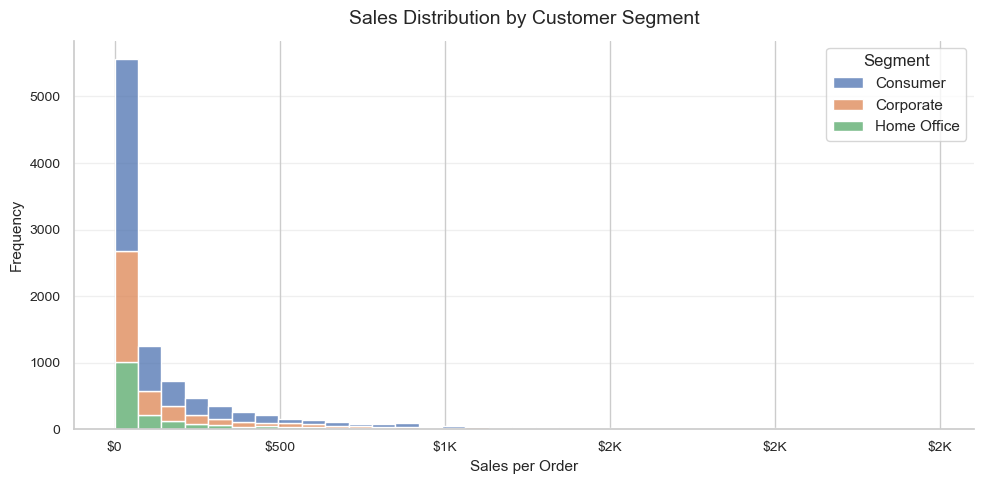

In [310]:
sales_visual_limit = clean_df["Sales"].quantile(0.99)
sales_distribution_df = clean_df[clean_df["Sales"] <= sales_visual_limit].copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=sales_distribution_df,
    x="Sales",
    hue="Segment",
    bins=35,
    multiple="stack",
    palette=SEGMENT_PALETTE,
    ax=ax
)

ax.set_title("Sales Distribution by Customer Segment", pad=12)
ax.set_xlabel("Sales per Order")
ax.set_ylabel("Frequency")
ax.xaxis.set_major_formatter(FuncFormatter(format_usd_millions))

legend = ax.get_legend()
if legend is not None:
    legend.set_title("Segment")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** La maggior parte degli ordini si concentra su valori di vendita più bassi, mentre gli ordini ad alto valore sono meno frequenti. Il grafico esclude l’1% superiore dei valori di vendita per migliorare la leggibilità e confrontare più chiaramente i segmenti cliente.

### 6.2 Sales and Profit by Category

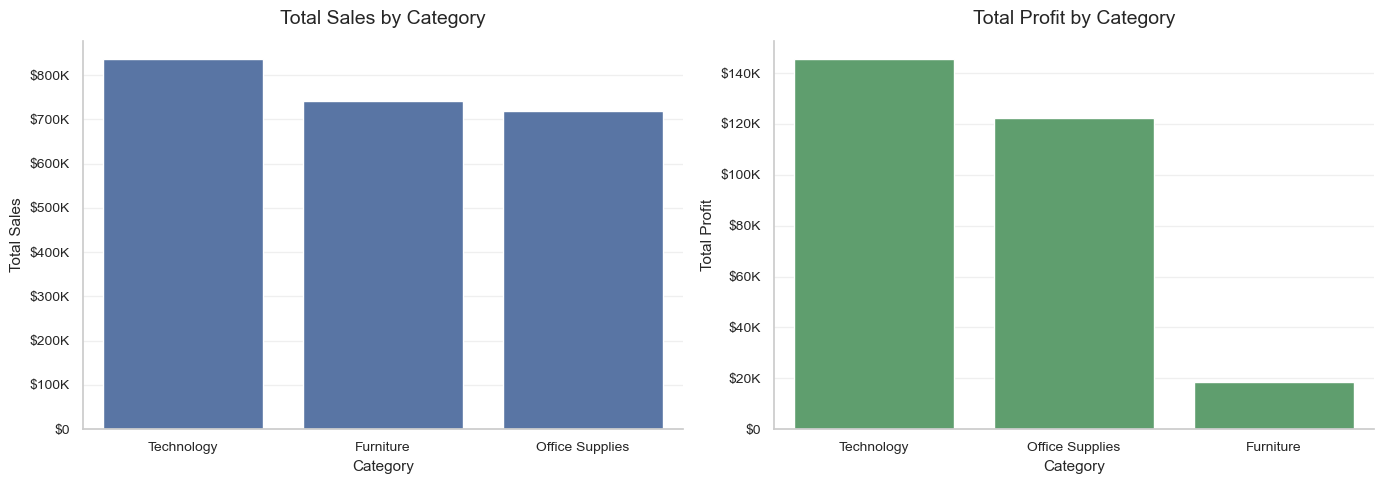

In [311]:
category_sales_sorted = category_summary.sort_values("Total_Sales", ascending=False)
category_profit_sorted = category_summary.sort_values("Total_Profit", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=category_sales_sorted,
    x="Category",
    y="Total_Sales",
    ax=axes[0],
    color=PRIMARY_COLOR
)

axes[0].set_title("Total Sales by Category", pad=12)
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Sales")
axes[0].yaxis.set_major_formatter(FuncFormatter(format_usd_millions))
axes[0].grid(axis="y", alpha=0.3)

sns.barplot(
    data=category_profit_sorted,
    x="Category",
    y="Total_Profit",
    ax=axes[1],
    color=SECONDARY_COLOR
)

axes[1].set_title("Total Profit by Category", pad=12)
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Total Profit")
axes[1].yaxis.set_major_formatter(FuncFormatter(format_usd_millions))
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** Le vendite e la redditività non seguono sempre lo stesso andamento tra le categorie. Questo confronto permette di distinguere il volume di ricavi dal contributo economico effettivo.

### 6.3 Profit and Profit Margin by Region

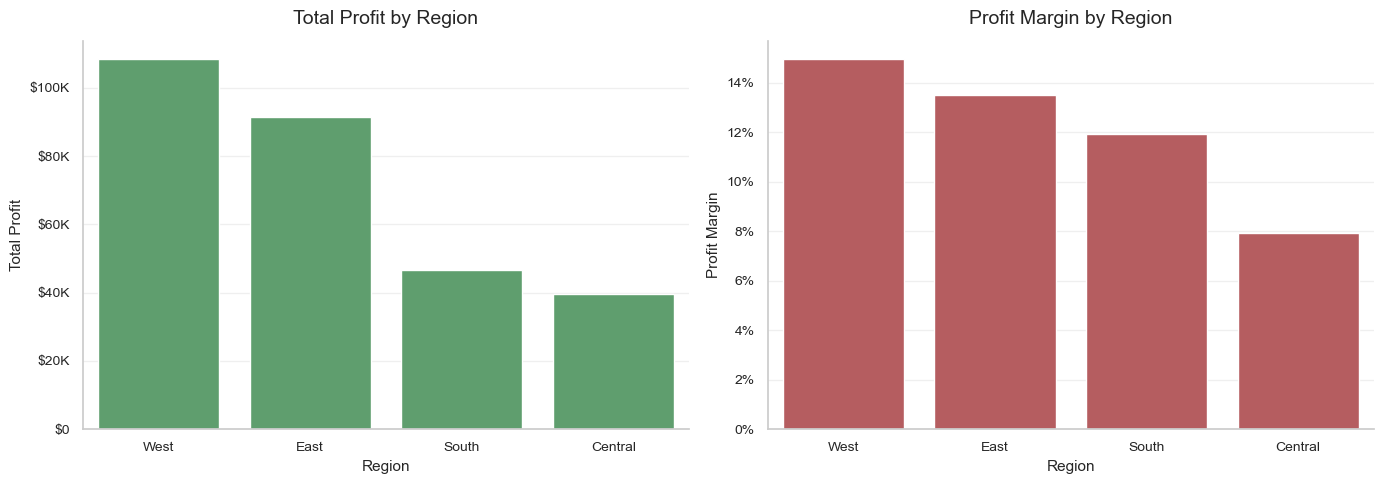

In [312]:
region_profit_sorted = region_summary.sort_values(
    "Total_Profit",
    ascending=False
)

region_margin_sorted = region_summary.sort_values(
    "Profit_Margin_Percent",
    ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=region_profit_sorted,
    x="Region",
    y="Total_Profit",
    ax=axes[0],
    color=SECONDARY_COLOR
)

axes[0].set_title("Total Profit by Region", pad=12)
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Total Profit")
axes[0].yaxis.set_major_formatter(FuncFormatter(format_usd_millions))
axes[0].grid(axis="y", alpha=0.3)

sns.barplot(
    data=region_margin_sorted,
    x="Region",
    y="Profit_Margin_Percent",
    ax=axes[1],
    color=ACCENT_COLOR
)

axes[1].set_title("Profit Margin by Region", pad=12)
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Profit Margin")
axes[1].yaxis.set_major_formatter(FuncFormatter(format_percent))
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** Le regioni non devono essere valutate solo in base al profitto totale. Il margine di profitto permette di osservare anche l’efficienza economica rispetto al volume di vendite.

### 6.4 Correlation Heatmap

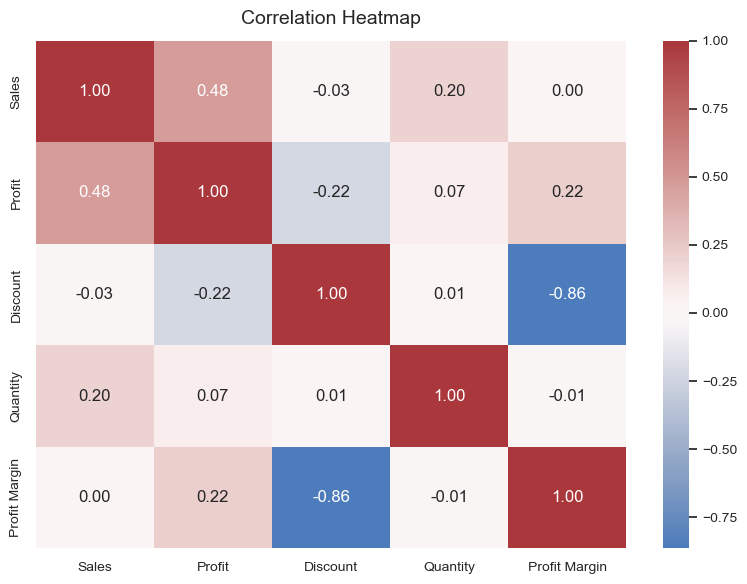

In [313]:
correlation_columns = ["Sales", "Profit", "Discount", "Quantity", "Profit Margin"]
correlation_matrix = clean_df[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    ax=ax
)

ax.set_title("Correlation Heatmap", pad=12)

plt.tight_layout()
plt.show()

**Insight:** La heatmap mostra le relazioni principali tra variabili numeriche come vendite, profitto, sconto, quantità e margine.

### 6.5 Monthly Sales Trend

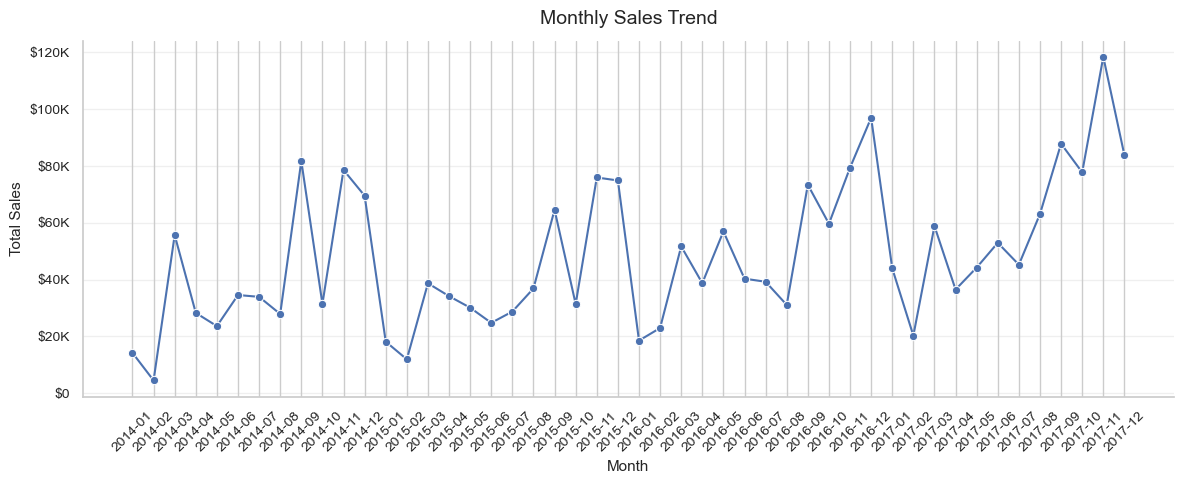

In [314]:
monthly_sales = (
    clean_df
    .groupby("YearMonth", as_index=False)
    .agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
    .sort_values("YearMonth")
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="YearMonth",
    y="Total_Sales",
    marker="o",
    color=PRIMARY_COLOR,
    ax=ax
)

ax.set_title("Monthly Sales Trend", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales")
ax.yaxis.set_major_formatter(FuncFormatter(format_usd_millions))
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Il trend mensile mostra come le vendite variano nel tempo, evidenziando possibili picchi stagionali o periodi di maggiore attività commerciale.

### 6.6 Average Profit by Discount Level

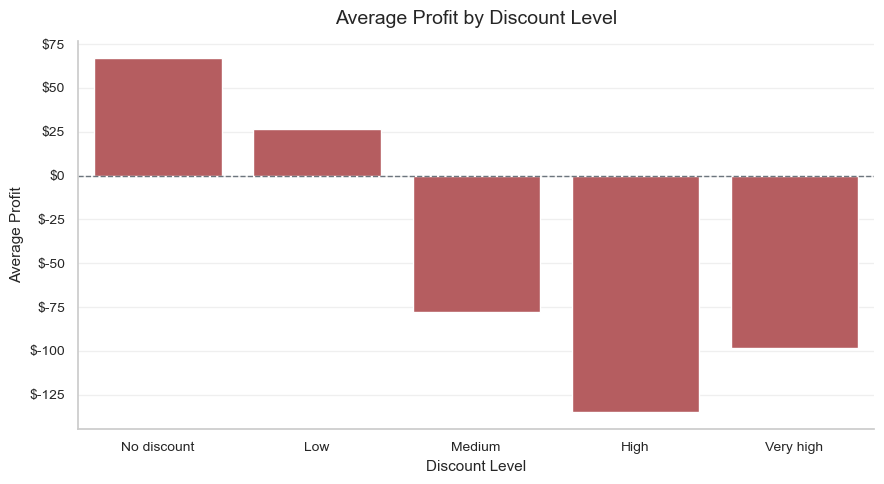

In [315]:
discount_bins = [-0.01, 0.00, 0.20, 0.40, 0.60, 1.00]
discount_labels = ["No discount", "Low", "Medium", "High", "Very high"]

clean_df["Discount Level"] = pd.cut(
    clean_df["Discount"],
    bins=discount_bins,
    labels=discount_labels
)

discount_profit = (
    clean_df
    .groupby("Discount Level", observed=False)["Profit"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=discount_profit,
    x="Discount Level",
    y="Profit",
    color=ACCENT_COLOR,
    ax=ax
)

ax.axhline(0, linestyle="--", linewidth=1, color=NEUTRAL_COLOR)
ax.set_title("Average Profit by Discount Level", pad=12)
ax.set_xlabel("Discount Level")
ax.set_ylabel("Average Profit")
ax.yaxis.set_major_formatter(FuncFormatter(format_usd_millions))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** Il profitto medio tende a diminuire quando aumenta il livello di sconto. Questo suggerisce che la strategia promozionale deve essere monitorata insieme alla redditività, non solo al volume di vendita.

### 6.7 Bottom 10 Sub-Categories by Profit

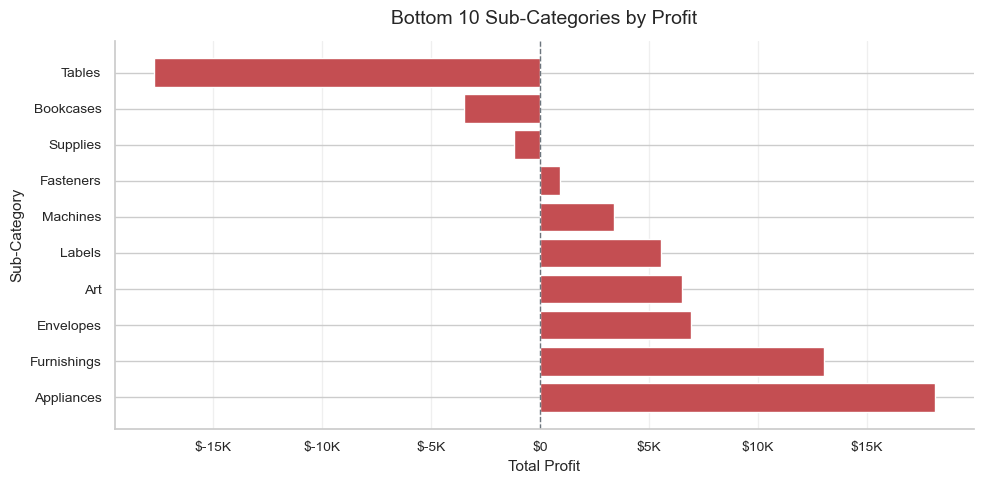

In [316]:
lowest_profit_subcategories = (
    subcategory_summary
    .sort_values("Total_Profit", ascending=True)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    lowest_profit_subcategories["Sub-Category"],
    lowest_profit_subcategories["Total_Profit"],
    color=ACCENT_COLOR
)

ax.axvline(0, linestyle="--", linewidth=1, color=NEUTRAL_COLOR)
ax.set_title("Bottom 10 Sub-Categories by Profit", pad=12)
ax.set_xlabel("Total Profit")
ax.set_ylabel("Sub-Category")
ax.xaxis.set_major_formatter(FuncFormatter(format_usd_millions))
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Insight:** Questo grafico identifica le sottocategorie più critiche in termini di profitto totale. Le perdite assolute aiutano a individuare le aree che richiedono maggiore attenzione commerciale.

### 6.8 Bottom 10 Sub-Categories by Profit Margin

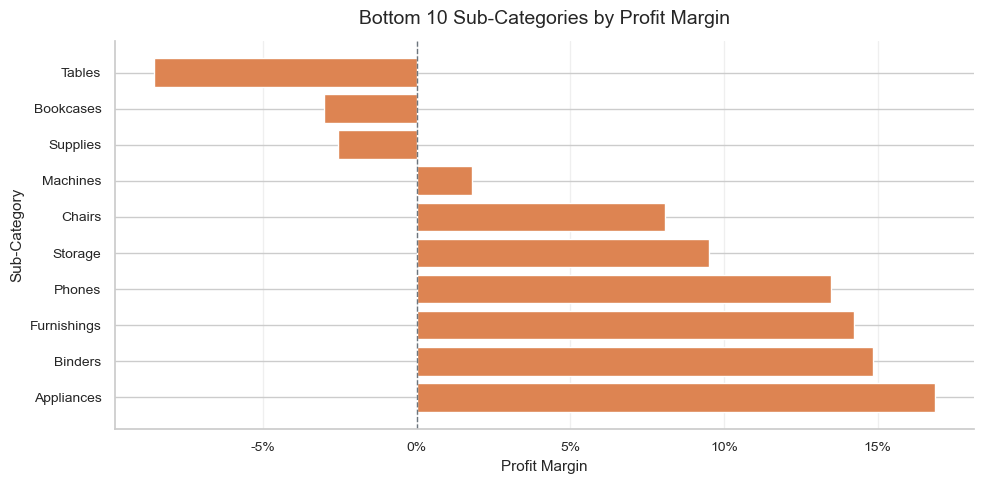

In [317]:
lowest_margin_subcategories = (
    subcategory_summary
    .sort_values("Profit_Margin_Percent", ascending=True)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    lowest_margin_subcategories["Sub-Category"],
    lowest_margin_subcategories["Profit_Margin_Percent"],
    color=WARNING_COLOR
)

ax.axvline(0, linestyle="--", linewidth=1, color=NEUTRAL_COLOR)
ax.set_title("Bottom 10 Sub-Categories by Profit Margin", pad=12)
ax.set_xlabel("Profit Margin")
ax.set_ylabel("Sub-Category")
ax.xaxis.set_major_formatter(FuncFormatter(format_percent))
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Insight:** Il margine di profitto aggiunge una prospettiva di efficienza. Alcune sottocategorie possono generare vendite, ma convertire male il fatturato in profitto.

### 6.9 High Sales but Low Margin

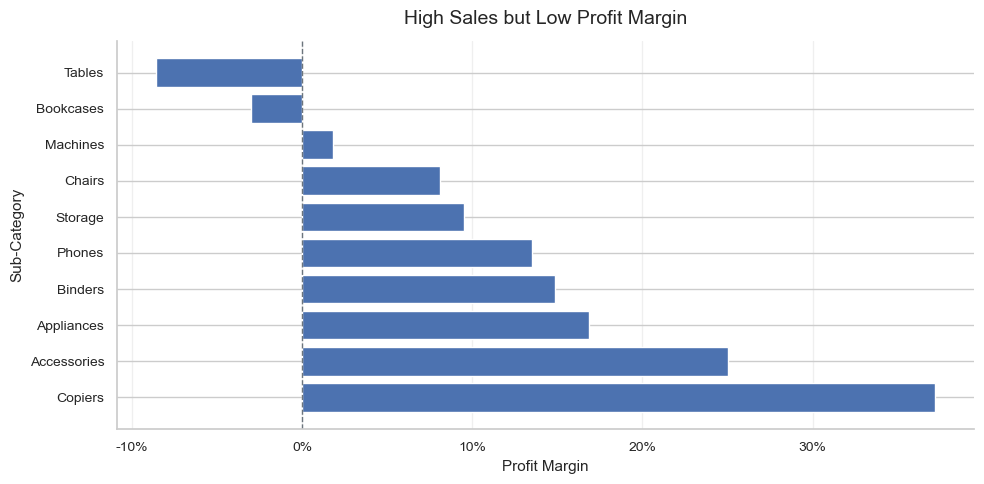

In [318]:
high_sales_low_margin = (
    subcategory_summary
    .sort_values("Total_Sales", ascending=False)
    .head(10)
    .sort_values("Profit_Margin_Percent", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    high_sales_low_margin["Sub-Category"],
    high_sales_low_margin["Profit_Margin_Percent"],
    color=PRIMARY_COLOR
)

ax.axvline(0, linestyle="--", linewidth=1, color=NEUTRAL_COLOR)
ax.set_title("High Sales but Low Profit Margin", pad=12)
ax.set_xlabel("Profit Margin")
ax.set_ylabel("Sub-Category")
ax.xaxis.set_major_formatter(FuncFormatter(format_percent))
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Insight:** Alcune sottocategorie con vendite elevate non generano una redditività proporzionale. Questo conferma che un alto volume di vendita deve essere valutato insieme al margine di profitto.

## 7. Main Insights

- Le vendite non coincidono sempre con la redditività. La categoria Technology genera il volume di vendite più alto, ma l’analisi del profitto mostra che è necessario valutare anche il margine e non solo il fatturato.
- Furniture rappresenta una categoria da monitorare con attenzione: pur avendo vendite elevate, mostra una redditività più debole rispetto ad altre categorie. Questo suggerisce possibili criticità legate a costi, prezzi o sconti applicati.
- A livello regionale, West ed East mostrano le performance più solide in termini di profitto complessivo. Tuttavia, il confronto con il margine di profitto evidenzia che le regioni devono essere valutate anche in termini di efficienza economica.
- La regione Central risulta meno efficiente rispetto alle altre: il profitto totale è positivo, ma il margine è più basso. Questo può indicare una maggiore pressione sugli sconti o una composizione di vendite meno redditizia.
- La distribuzione delle vendite è concentrata soprattutto su importi bassi e medi, con pochi ordini di valore molto elevato. Questo indica che la maggior parte delle transazioni riguarda acquisti relativamente contenuti.
- L’analisi degli sconti mostra un pattern chiaro: quando il livello di sconto aumenta, il profitto medio tende a diminuire. Questo suggerisce che la strategia promozionale dovrebbe essere controllata con maggiore attenzione.
- Alcune sottocategorie generano perdite significative in termini assoluti, in particolare Tables, Bookcases e Supplies. Queste aree dovrebbero essere analizzate per capire se il problema dipende da prezzi, costi, sconti o gestione commerciale.
- Il confronto tra profitto totale e margine di profitto aggiunge una prospettiva più completa: alcune sottocategorie non solo generano perdite, ma trasformano anche male le vendite in profitto.
- Alcune sottocategorie con vendite elevate, come Tables, Machines o Chairs, non mostrano una redditività proporzionale al volume generato. Questo conferma che vendere di più non significa necessariamente guadagnare di più.
- Il trend mensile delle vendite mostra variazioni nel tempo, con picchi in alcuni periodi dell’anno. Questo tipo di informazione può essere utile per pianificare campagne commerciali, gestione dello stock e attività promozionali.
## 8. Recommendations

- Monitorare con maggiore attenzione le sottocategorie con profitto negativo.
- Valutare una revisione della strategia di sconto, soprattutto quando gli sconti non generano profitto sufficiente.
- Usare le regioni più redditizie come riferimento per comprendere pratiche commerciali efficaci.
- Analizzare separatamente i segmenti cliente per adattare offerte e comunicazione commerciale.
- Integrare l’analisi con dati sui costi operativi per capire meglio le cause delle perdite.

## 9. Limitations and Conclusion

Il dataset Superstore permette di osservare pattern utili su vendite, profitto, sconti, regioni e categorie. L’analisi suggerisce che la redditività non dipende solo dal volume delle vendite, ma anche dalla gestione degli sconti e dalla performance delle singole sottocategorie.